# JEM - Coupling Quick Start

This notebook demonstrates a JAX-ESM (JEM) example using JAX-GCM (JCM) and Slab Ocean Model as an aquaplanet.

## Import Packages

In [1]:
import os, sys
from pathlib import Path

# or `export PYTHONPATH=/path/to/jax-esm/root/directory`
sys.path.append( (Path(os.getcwd()) / ".." ).resolve())

In [2]:
import jcm
from jcm.geometry import Geometry
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

## Configurations

In [3]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
output_dir = Path("output/JCM_SOM").resolve()
output_dir.mkdir(exist_ok=True, parents=True)
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [4]:
# Creating regridders and mapping
identity = lambda x: x
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
)

## Create Components

In [5]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active = False,
)

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            start_datetime=start_datetime,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No mask_file given. Set fmask = 0.
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ diffusion <str>: DiffusionFilter(vor_q_timescale=43200, vor_q_order=2, temp_timescale=86400, temp_order=2, div_timescale=7200, div_order=1)
│   └── ● ocn <dict>
│       └── ○ relaxation_time

## Run Coupled Model

In [18]:
simulation_interval = jdt.to_timedelta(60, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/nump

Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, atm, ocn
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux
Using method: None


Simulation:   0%|          | 0/60 [00:00<?, ?it/s]

## Output into NetCDF

In [19]:
output_dict = model.predictions_to_xarray(predictions)
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print("Output file: ", str(output_file))
    ds.to_netcdf(output_file, engine="netcdf4")

nodal_shape =  (8, 96, 48)
data.keys =  ['u_wind', 'v_wind', 'temperature', 'specific_humidity', 'geopotential', 'normalized_surface_pressure', 'shortwave_rad.qcloud', 'shortwave_rad.fsol', 'shortwave_rad.rsds', 'shortwave_rad.rsns', 'shortwave_rad.ozone', 'shortwave_rad.ozupp', 'shortwave_rad.zenit', 'shortwave_rad.stratz', 'shortwave_rad.gse', 'shortwave_rad.icltop', 'shortwave_rad.cloudc', 'shortwave_rad.cloudstr', 'shortwave_rad.ftop', 'shortwave_rad.dfabs', 'shortwave_rad.compute_shortwave', 'longwave_rad.dfabs', 'longwave_rad.ftop', 'convection.se', 'convection.iptop', 'convection.cbmf', 'convection.qdif', 'convection.precnv', 'mod_radcon.ablco2', 'mod_radcon.alb_l', 'mod_radcon.alb_s', 'mod_radcon.albsfc', 'mod_radcon.snowc', 'humidity.rh', 'humidity.qsat', 'condensation.precls', 'condensation.dtlsc', 'condensation.dqlsc', 'surface_flux.rlds', 'surface_flux.rlns', 'surface_flux.tsfc', 'surface_flux.tskin', 'surface_flux.u0', 'surface_flux.v0', 'surface_flux.t0', 'date.tyear', 'd

## Visualization

In [8]:
import matplotlib.pyplot as plt

### Atmosphere

In [9]:
ds = output_dict["atm"]
print(str(ds))

<xarray.Dataset> Size: 37MB
Dimensions:                          (time: 10, lon: 96, lat: 48, level: 8)
Coordinates:
  * lon                              (lon) float64 768B 0.0 3.75 ... 352.5 356.2
  * lat                              (lat) float64 384B -87.16 -83.48 ... 87.16
  * level                            (level) float32 32B 0.95 0.835 ... 0.025
  * time                             (time) datetime64[ns] 80B 2000-01-01 ......
Data variables: (12/79)
    surface_flux.u0                  (time, lon, lat) float32 184kB ...
    date.model_year                  (time) float32 40B ...
    humidity.qsat                    (time, level, lon, lat) float32 1MB ...
    mod_radcon.st4a.1                (time, level, lon, lat) float32 1MB ...
    shortwave_rad.compute_shortwave  (time) float32 40B ...
    convection.se                    (time, level, lon, lat) float32 1MB ...
    ...                               ...
    shortwave_rad.cloudstr           (time, lon, lat) float32 184kB ...
  

#### Precipitation

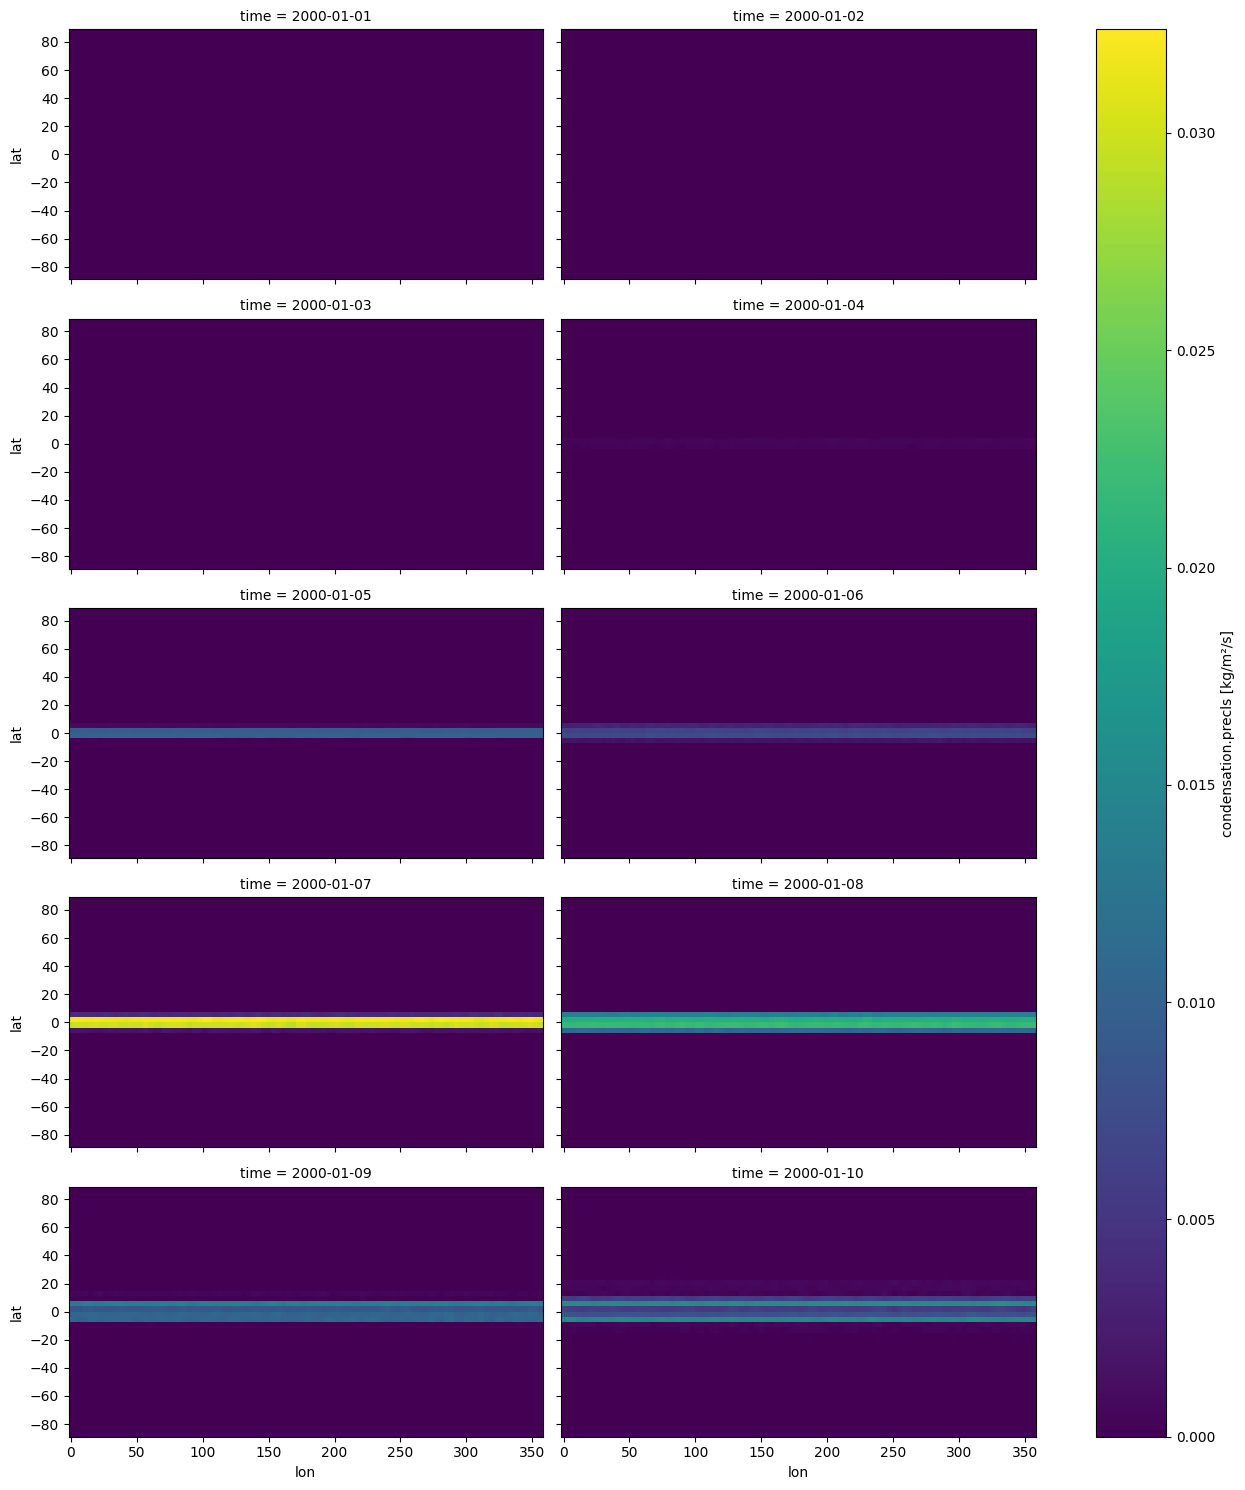

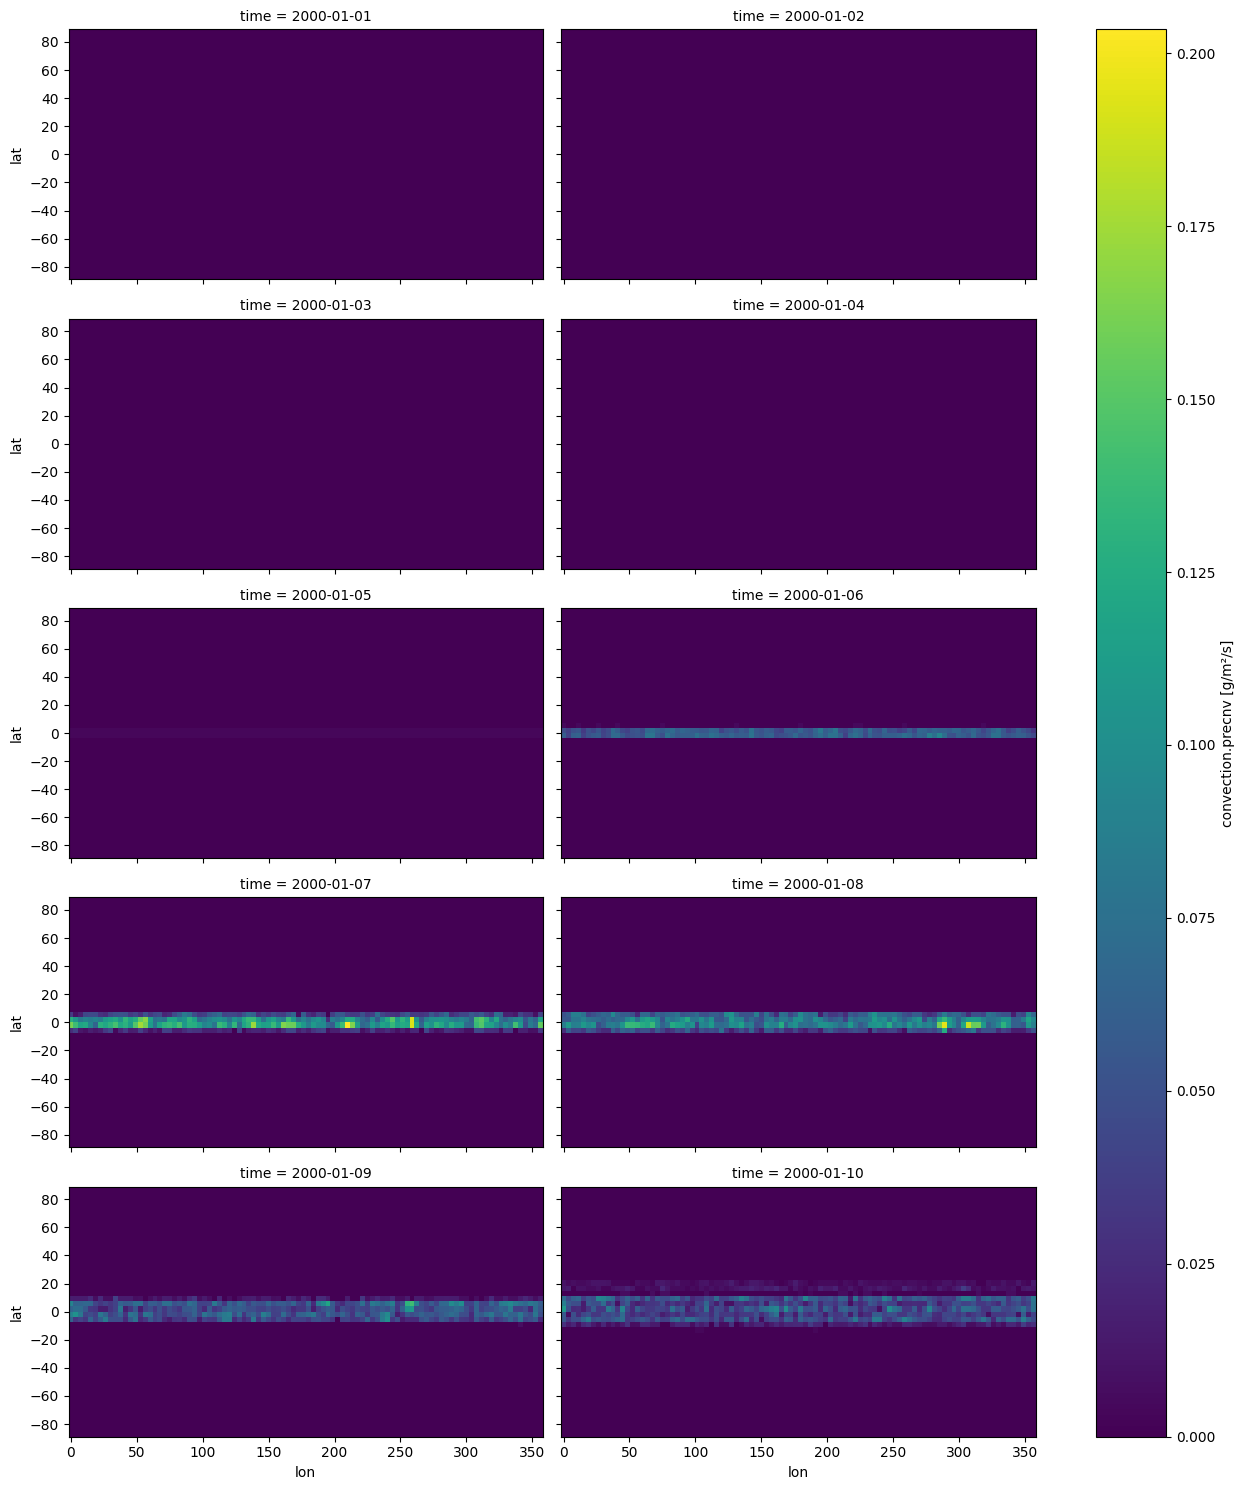

In [10]:
ds['condensation.precls'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
ds['convection.precnv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

#### Moisture

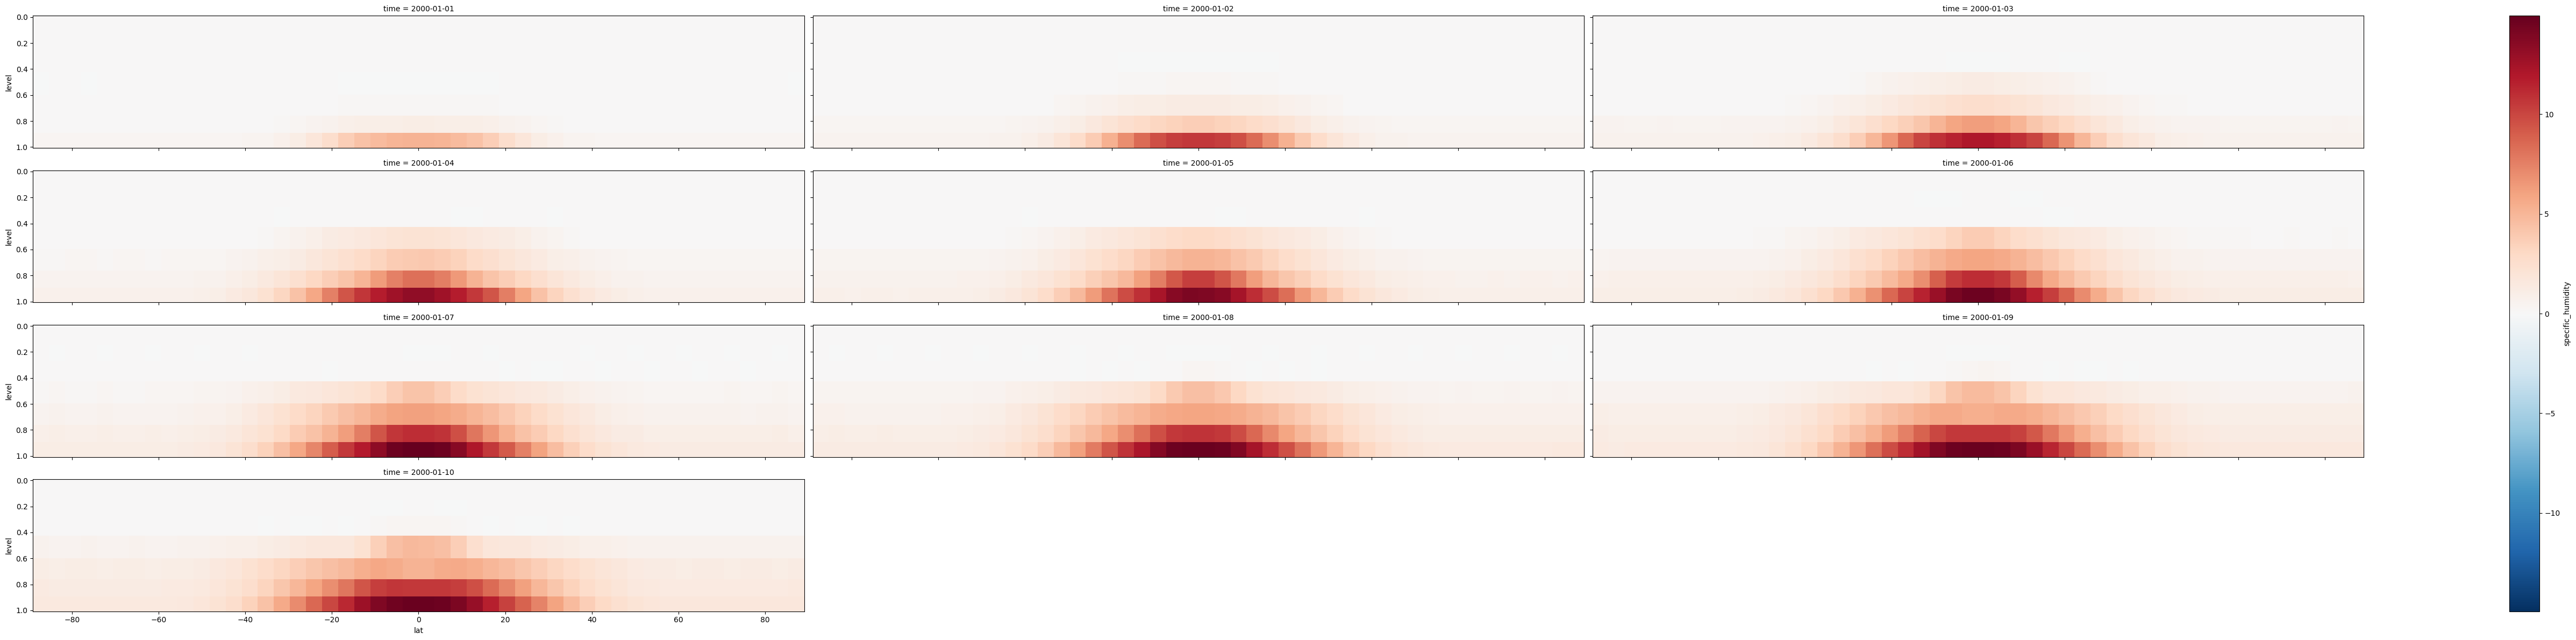

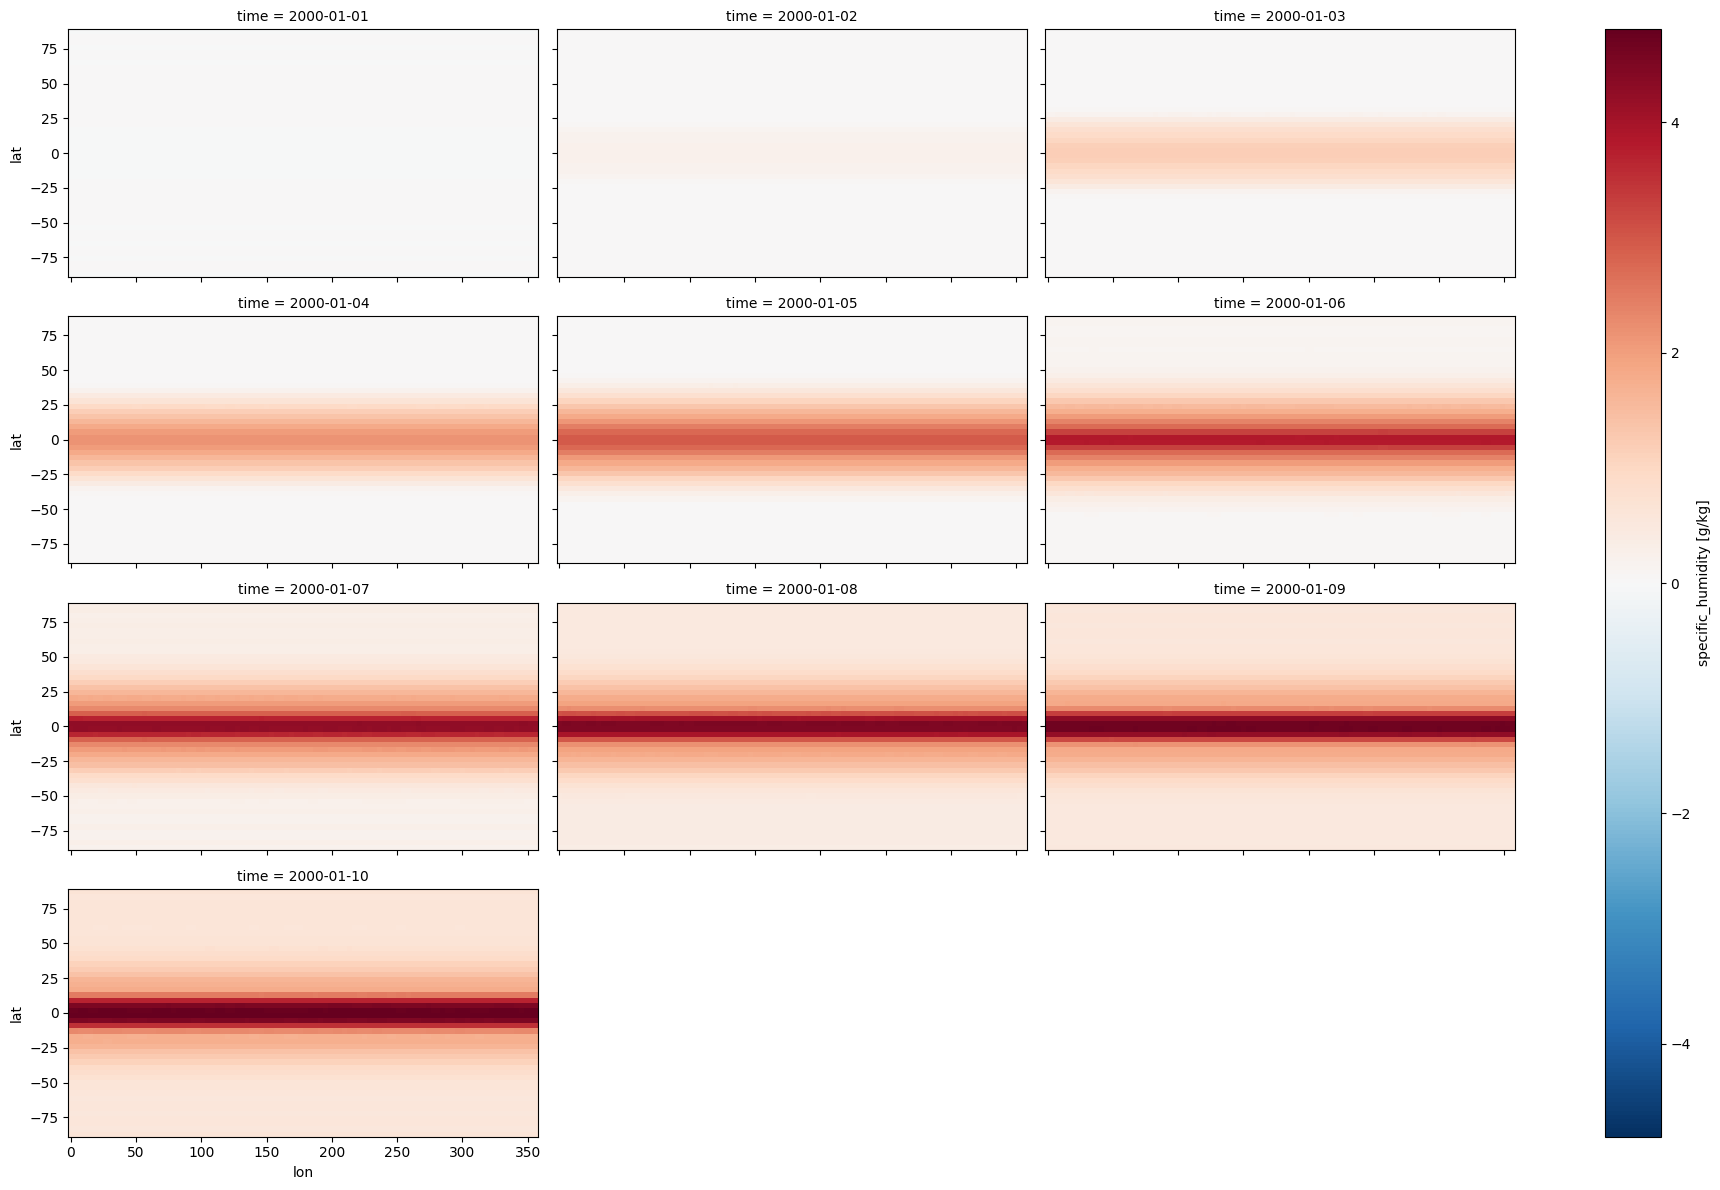

In [11]:
ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

#### Clouds

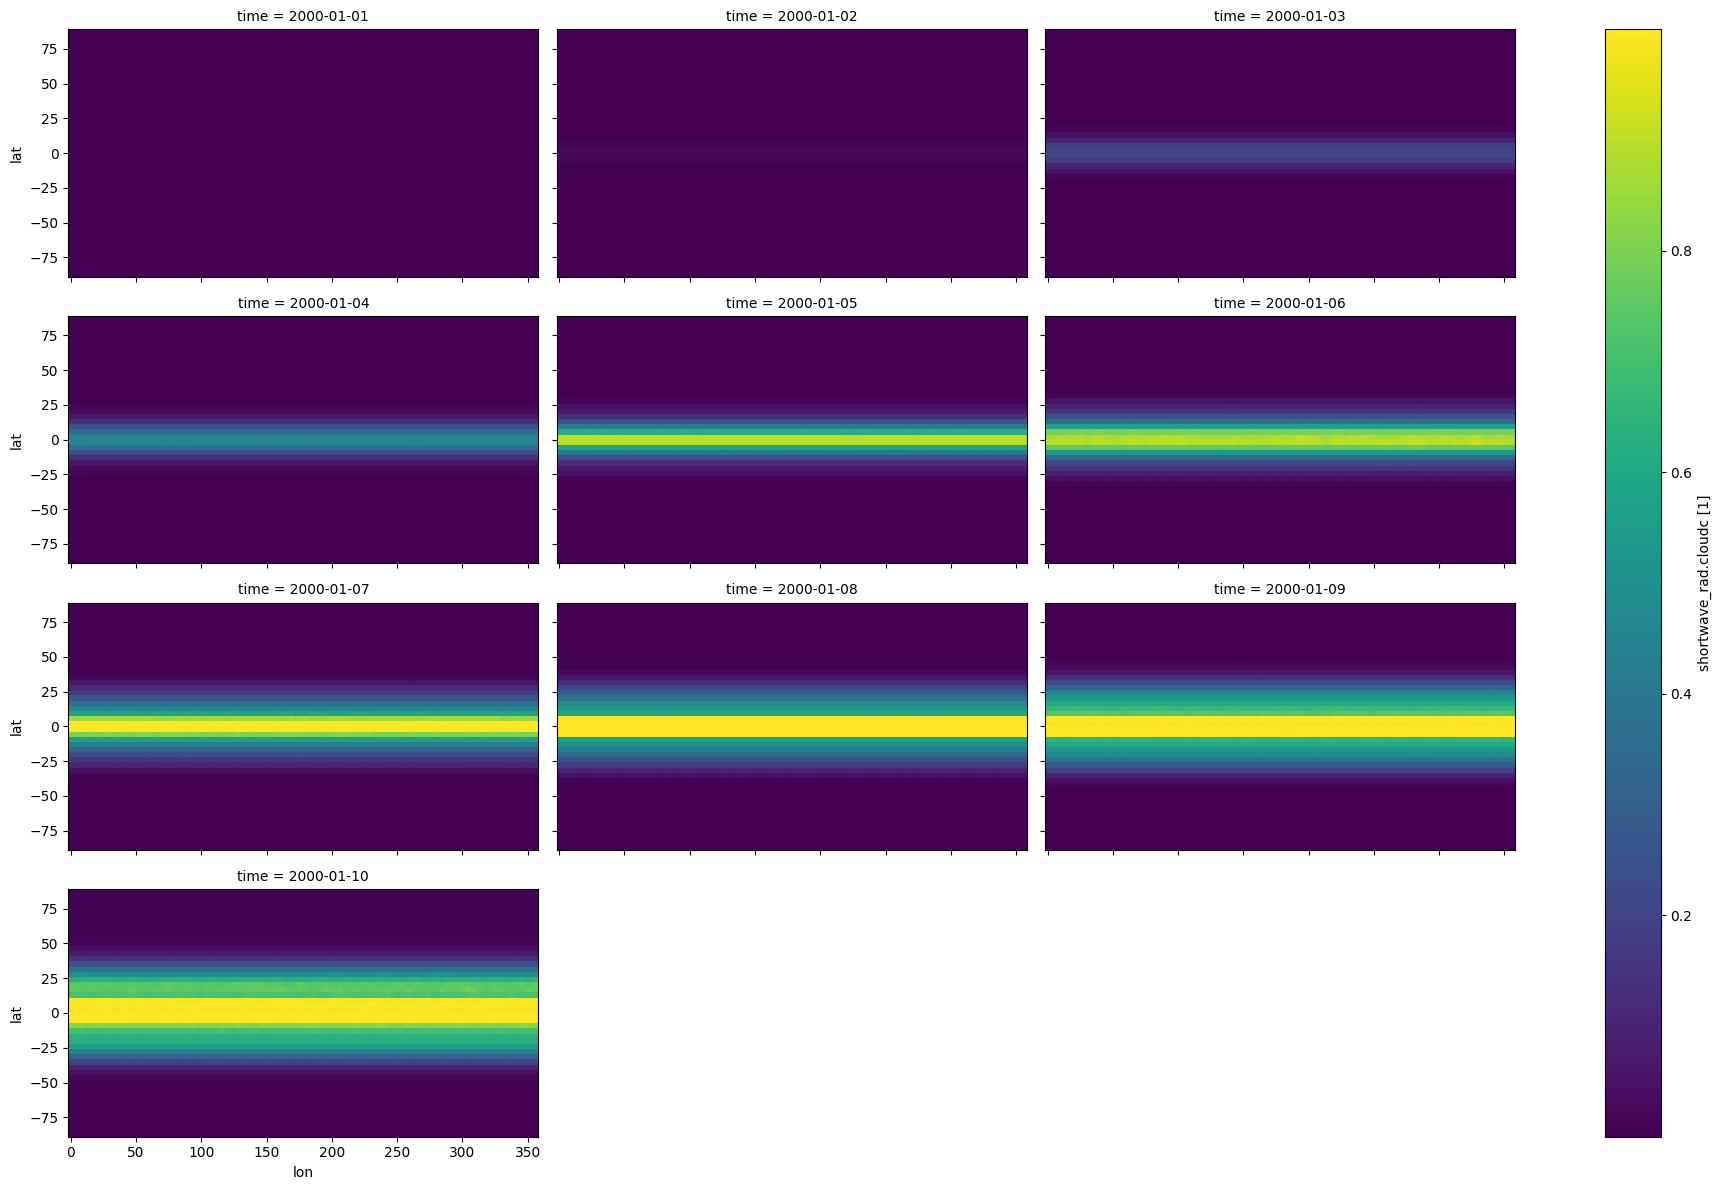

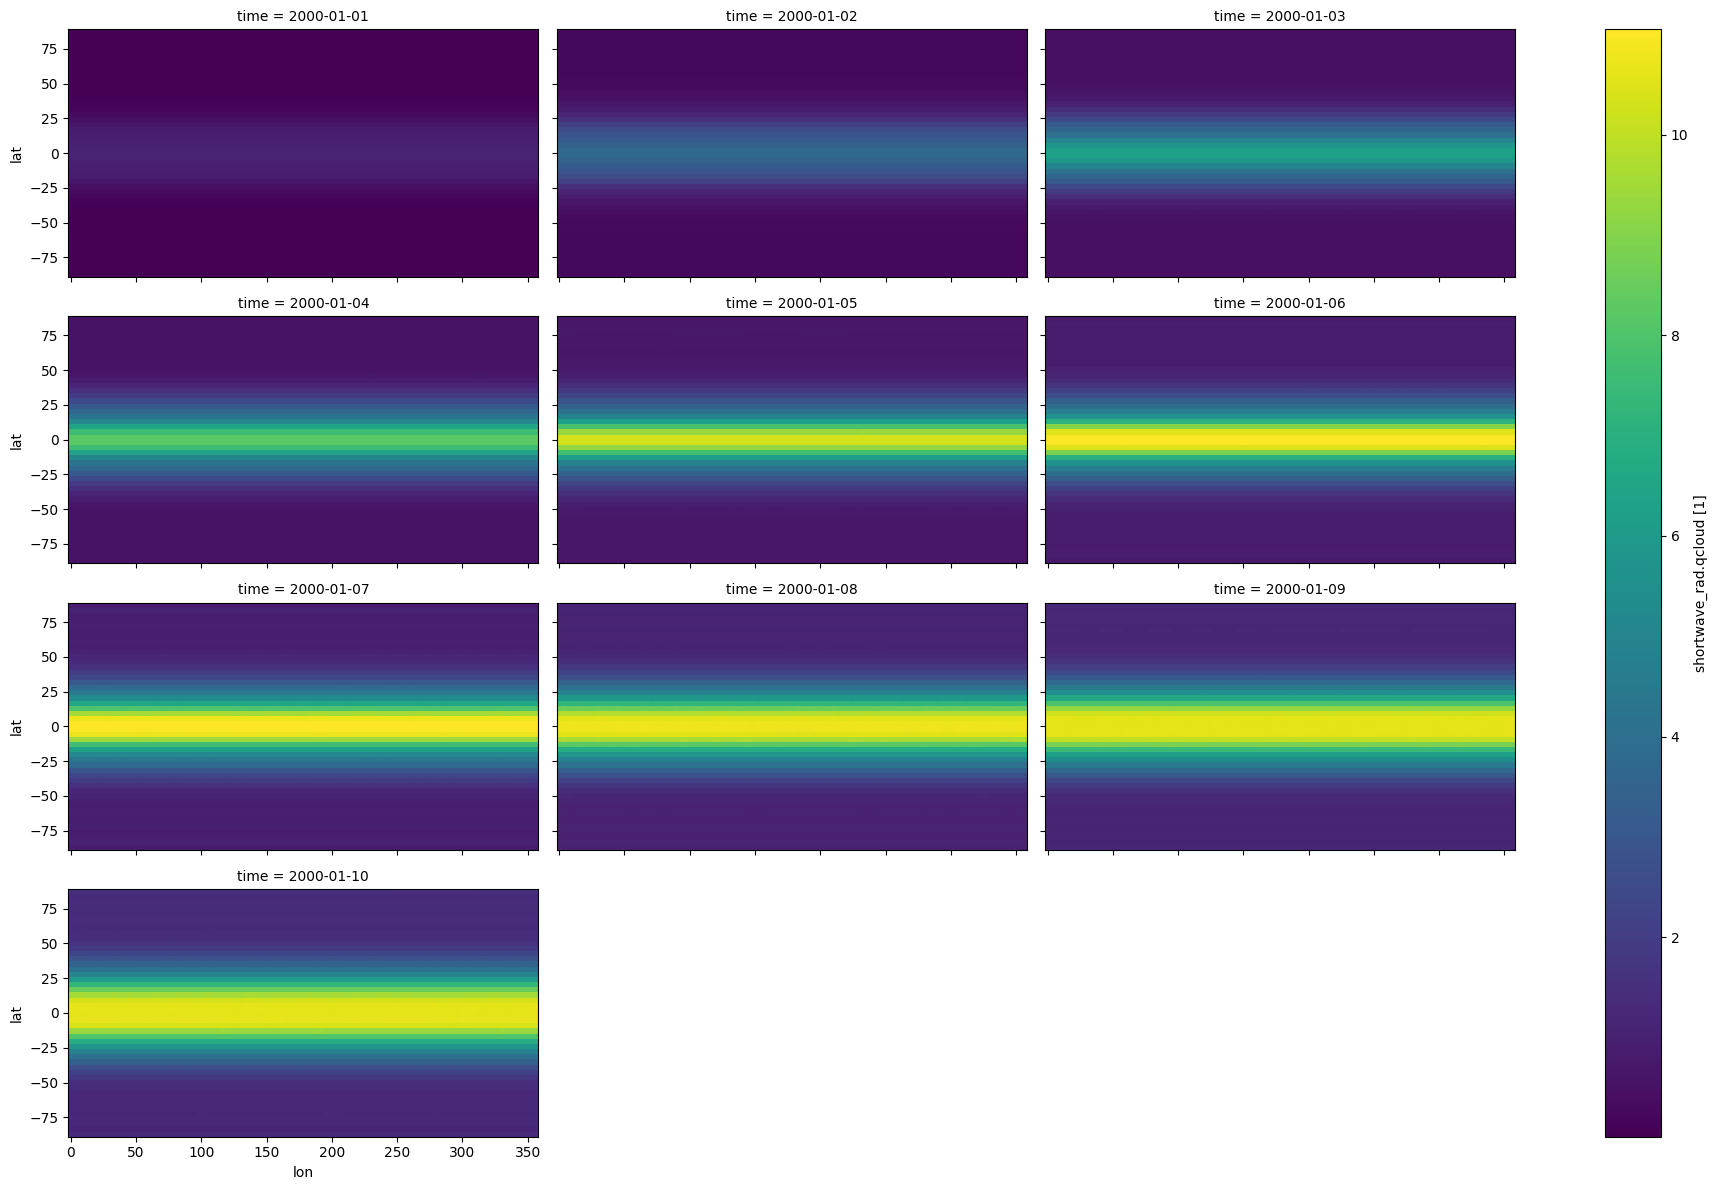

In [12]:
ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Ocean

In [13]:
ds = output_dict["ocn"]
print(str(ds))

<xarray.Dataset> Size: 590kB
Dimensions:                  (time: 10, longitude: 96, latitude: 48)
Coordinates:
  * time                     (time) float32 40B 24.0 48.0 72.0 ... 216.0 240.0
    latitude2D               (longitude, latitude) float32 18kB ...
    longitude2D              (longitude, latitude) float32 18kB ...
Dimensions without coordinates: longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float32 184kB ...
    mixed_layer_depth        (time, longitude, latitude) float32 184kB ...
    total_heat_flux          (time, longitude, latitude) float32 184kB ...


#### Sea Surface Temperature
We plot both the SST and its difference with respect to the initial condition.

Text(0.5, 0.98, 'Sea Surface Temperature [${}^\\circ \\mathrm{C}$]')

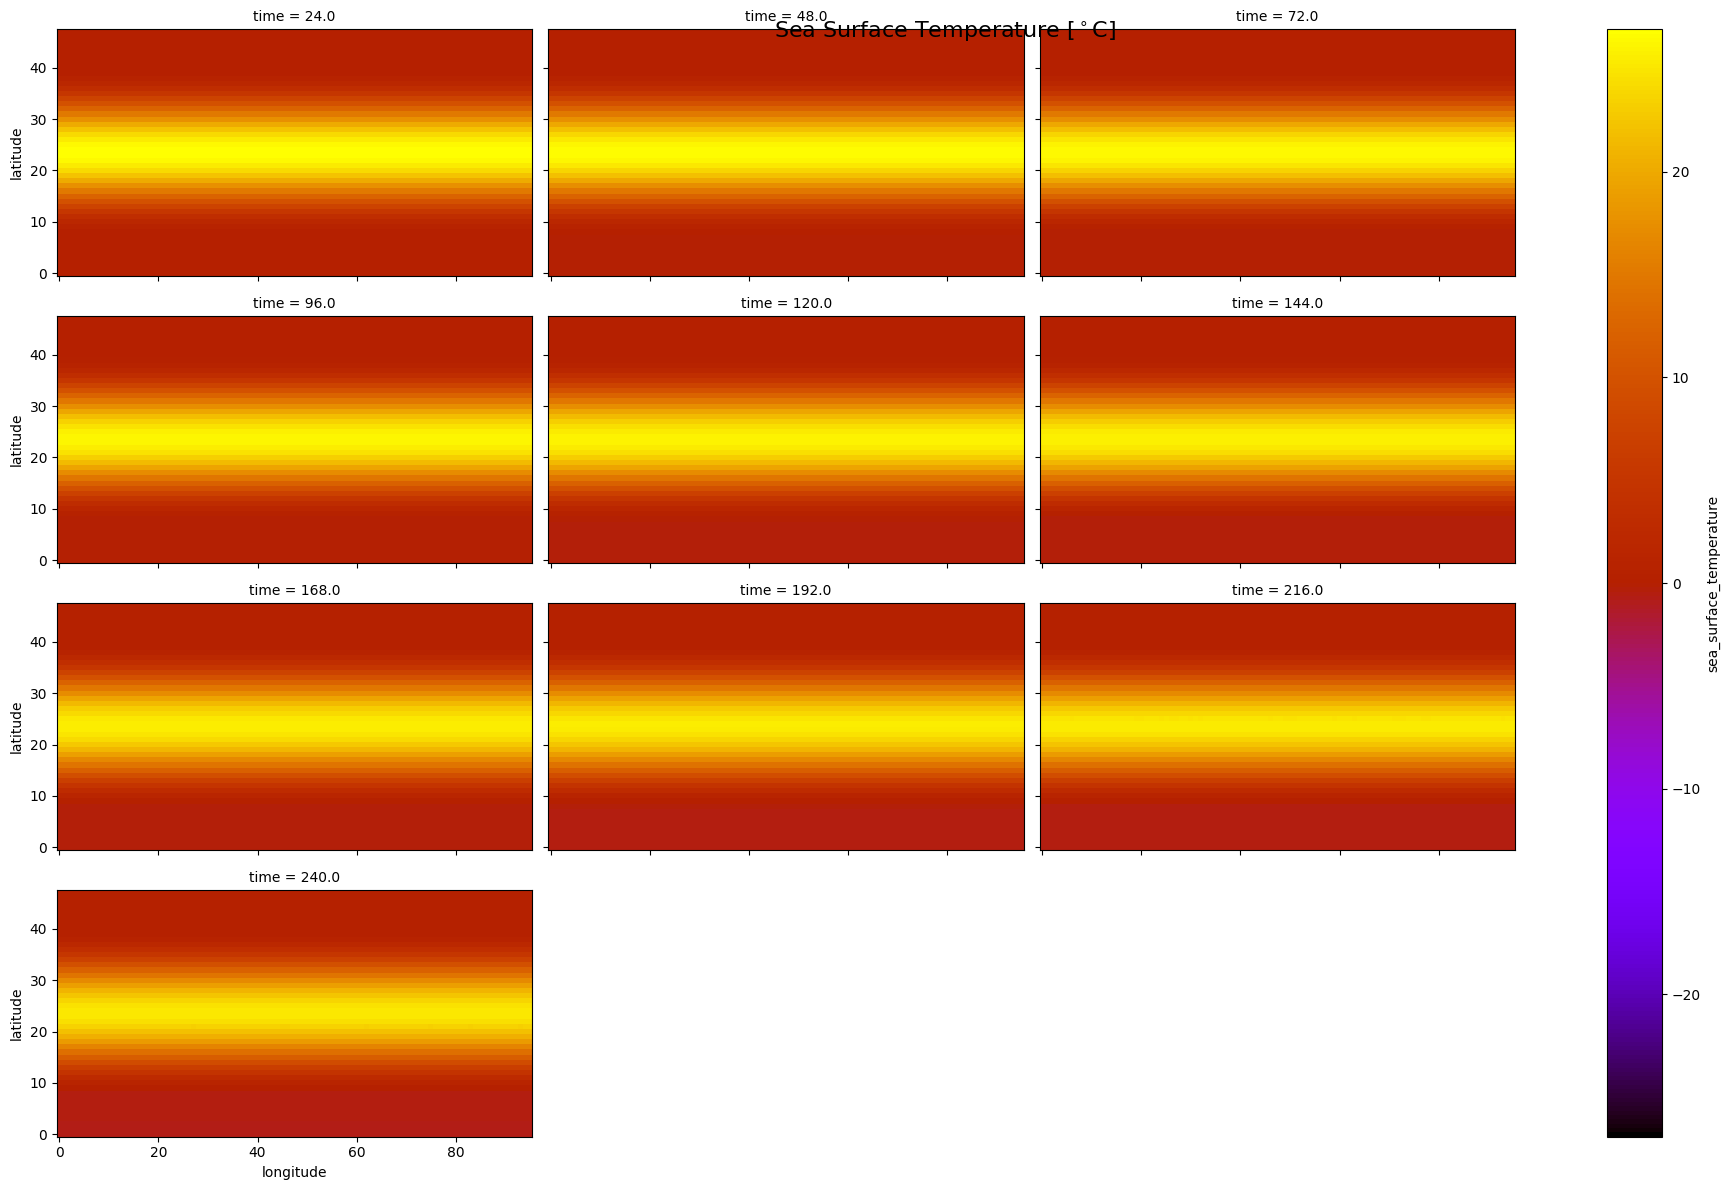

In [14]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="gnuplot")
g.fig.suptitle("Sea Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16)

Text(0.5, 0.98, 'Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]')

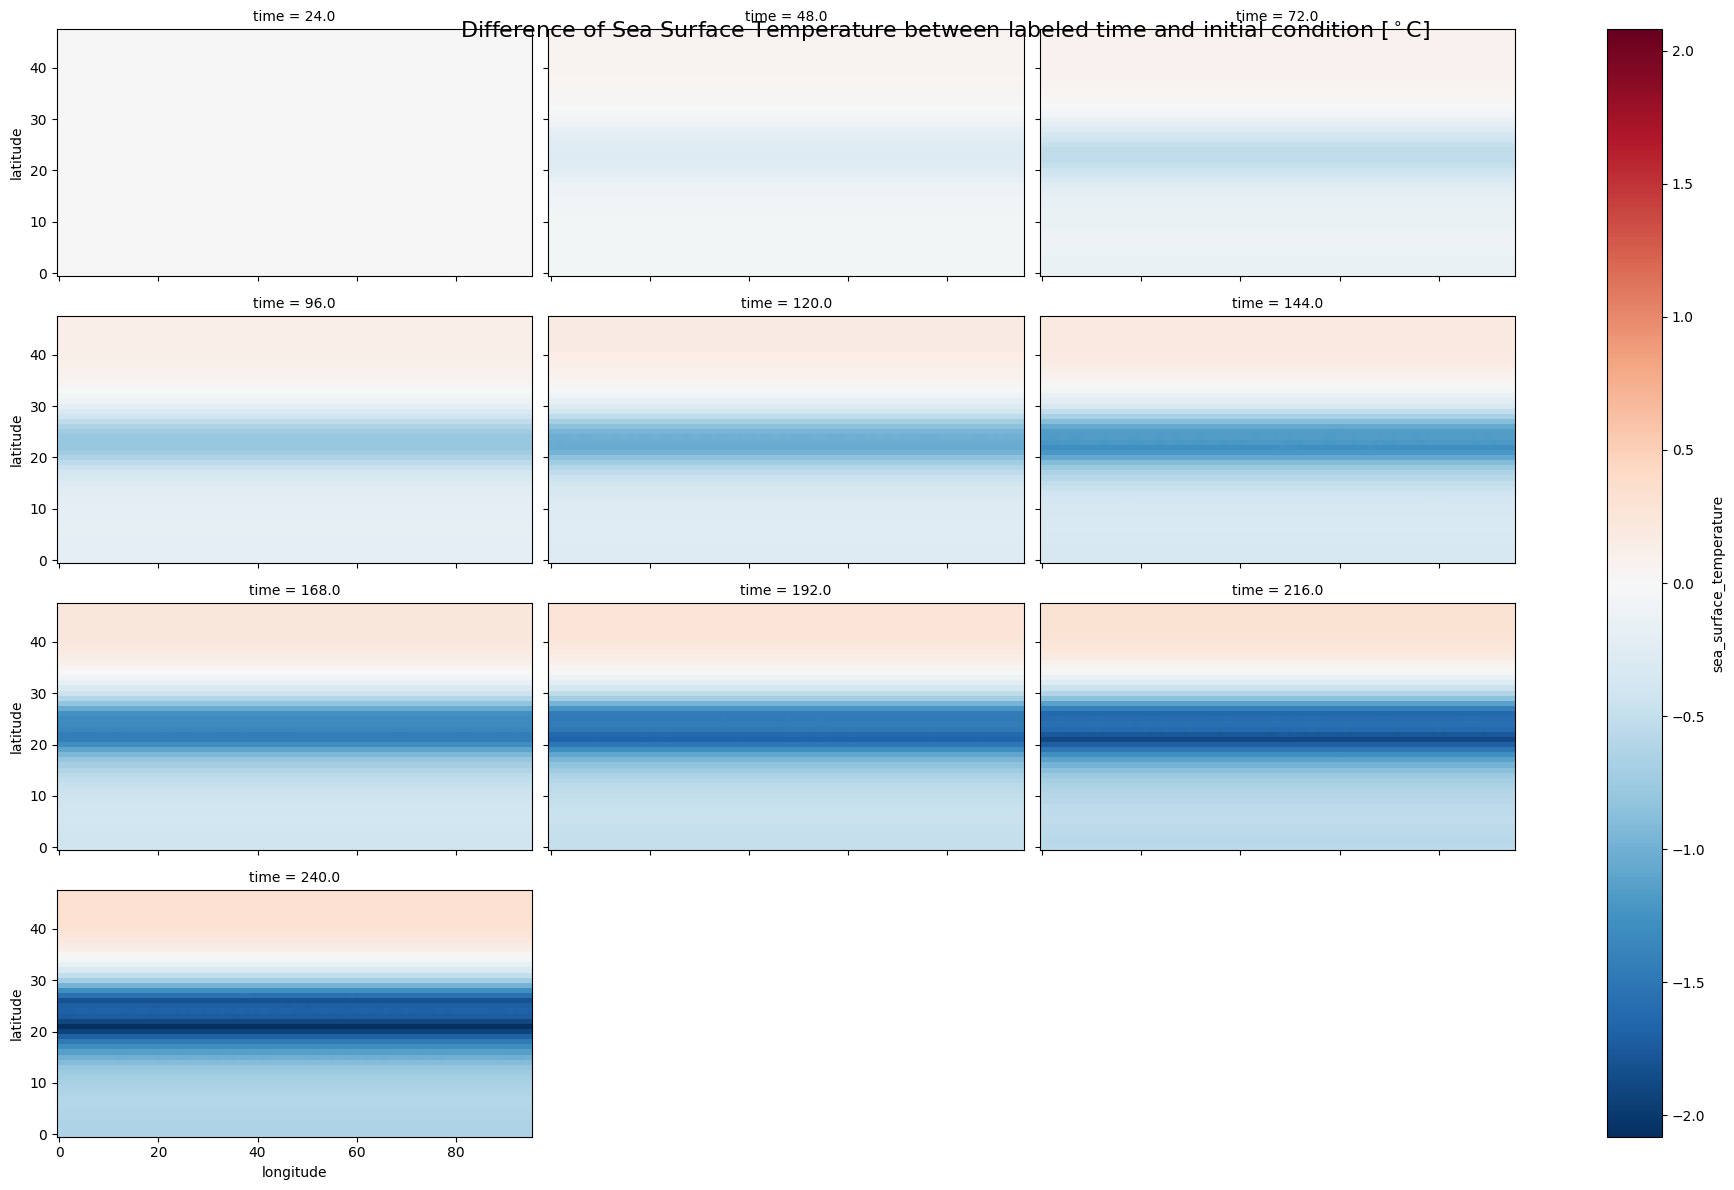

In [15]:
g = (ds['sea_surface_temperature'] - ds['sea_surface_temperature'].isel(time=0)).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, center=0)
g.fig.suptitle("Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]", fontsize=16)

#### Total heat flux

Text(0.5, 0.98, 'Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]')

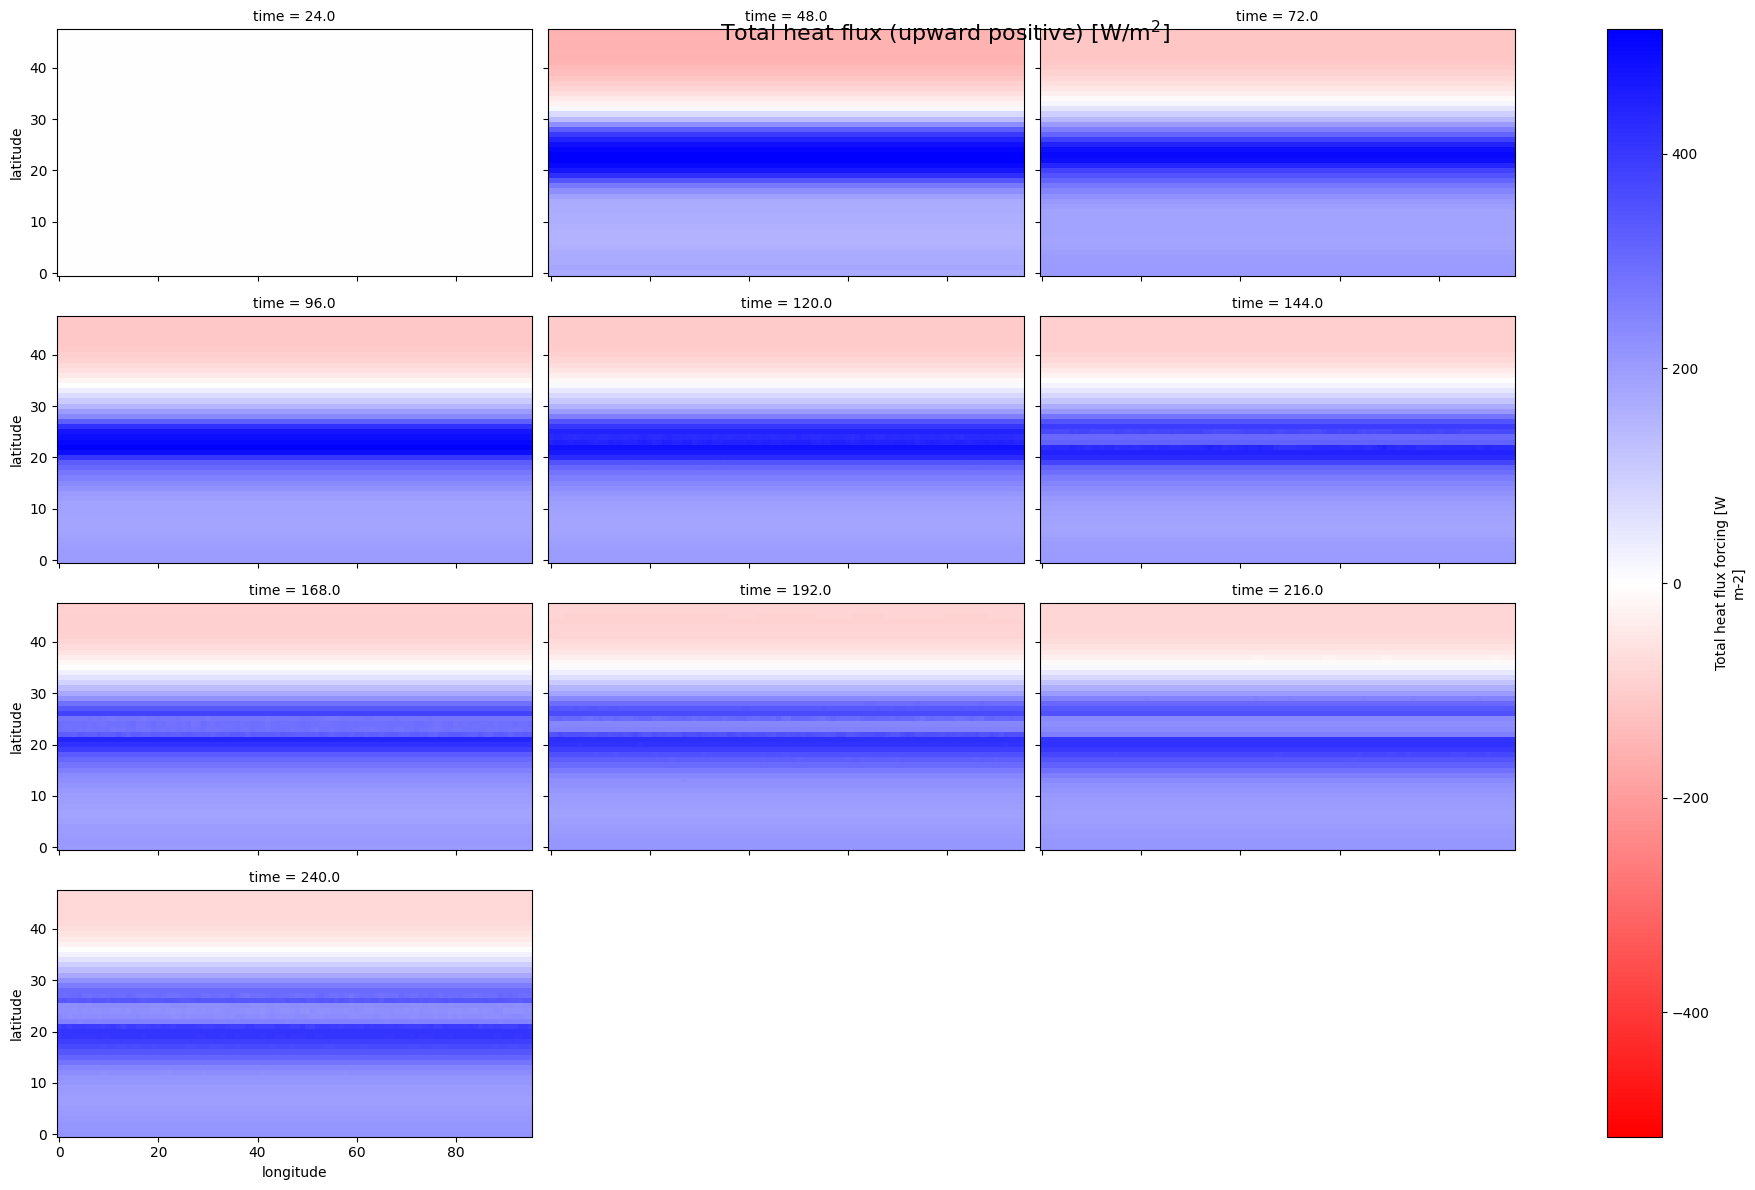

In [16]:
g = ds['total_heat_flux'].plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="bwr_r", center=0.0)
g.fig.suptitle("Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]", fontsize=16)

In [17]:
plt.show()